### 网络优化方法
1. Epoch: 使用全部数据对模型进行一次完整的训练，训练轮次
2. Batch_size: 使用训练集中的小部分样本对模型权重进行反向传播的参数更新，每次训练每批次样本数量
3. Iteration: 使用一个 Batch 数据都模型进行一次参数更新的过程

在深度学习中，梯度下降的几种方式根本区别就在于Batch Size不同，如下表：

| 梯度下降方式 | Training Set Size | Batch Size | Number of Batches |
|:--- |:------------------|:--- |:------------------|
| BGD | N                 | N | 1                 |
| SGD | N                 | 1 | N                 |
| Mini-Batch | N                 | B | N/B + 1           |

注：上表中 Mini-Batch 的Batch个数为 N/B + 1是针对未整除的情况。整除则是N/B 直接用 (N + B - 1)/B 替代

### 反向传播（BP算法）
前向传播：指的是数据输入到神经网络中，逐层向前传输，一直运算到输出层为止。
反向传播(Back Propagation)：利用损失函数 Error 值，从后向前，结合梯度下降算法，依次求各个参数的偏导，并进行参数更新。
**反向传播算法利用链式法则对神经网络中的各个节点的权重进行更新。**


### 梯度下降优化方法
梯度下降优化算法中，可能会碰到以下情况：
1. 碰到平缓区域，梯度值较小，参数优化变慢
2. 碰到”鞍点“，梯度为0，参数无法优化
3. 碰到局部最小值，参数不是最优
对于这些问题，出现了一些对梯度下降算法的优化方法，如：Momentum，AdaGrad，RMSprop，Adam等

#### 指数加权平均
**指数移动加权平均**是参考各数值，并且各数值的权重都不同，距离越远的数字对平均数计算的贡献就越小（权重较小），距离越近则对平均数的计算贡献越大（权重越大）。
指数加权平均不是梯度下降的优化方式，而是后续学习中对于 动量法：Momentum；自适应学习率：AdaGrad, RMSProp；自适应动量法：Adam。这四种方式底层公式要用到：指数移动加权平均。
例如：明天气温怎么样，和昨天气温有很大关系，但和一个月前的气温关系就小一些。
计算公式可以用下面的式子来表示：
$$ S_t = \begin{cases} Y_1 && t=0 \\ \beta * S_{t - 1} + (1 - \beta) * Y_t && t > 0 \end{cases} $$
1. $ S_t $为第t个时间点的指数加权平均值
2. $ Y_t $为第t个时间点的数值
3. $ \beta $为调节权重系数，该值越大平均数越平缓。一般取0.9-0.99

tensor([ 19.2692,  14.8728,   9.0072, -21.0552,   6.7842, -12.3454,  -0.4307,
        -16.0467,  -7.5214,  16.4872,  -3.9248, -14.0361,  -7.2788,  -5.5943,
        -23.1692,  -2.1680, -13.8467,  -8.7124,  -2.2337,  17.1736,   3.1888,
         -4.2452,  -8.2855,   3.3090, -15.5757,   9.9564,  -8.7979,  -6.0114,
        -12.7415,  21.2279])


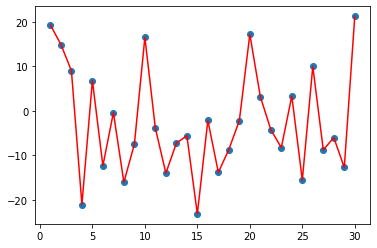

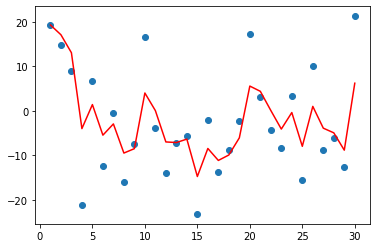

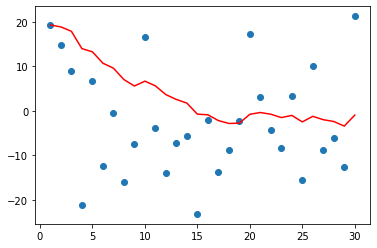

In [1]:
import torch
import matplotlib.pyplot as plt

ELEMENT_NUMBER = 30

def normal_temperature():
    torch.manual_seed(42)
    temperature = torch.randn(size=[ELEMENT_NUMBER, ]) * 10
    print(temperature)
    days = torch.arange(1, ELEMENT_NUMBER + 1, 1)
    plt.plot(days, temperature, color='red')
    plt.scatter(days, temperature)
    plt.show()

def exponential_moving_average(beta=0.9):
    torch.manual_seed(42)
    temperature = torch.randn(size=[ELEMENT_NUMBER, ]) * 10
    exp_weight_avg = []
    for idx, temp in enumerate(temperature, 1):
        if idx == 1:
            exp_weight_avg.append(temp)
            continue
        new_temp = exp_weight_avg[idx - 2] * beta + (1 - beta) * temp
        exp_weight_avg.append(new_temp)
    days = torch.arange(1, ELEMENT_NUMBER + 1, 1)
    plt.plot(days, exp_weight_avg, color='red')
    plt.scatter(days, temperature)
    plt.show()


if __name__ == '__main__':
    normal_temperature()
    exponential_moving_average(0.5)
    exponential_moving_average(0.9)


#### 动量算法Momentum
只从梯度角度入手，对参数进行优化。
梯度计算公式：$ s_t = \beta * s_{t - 1} + (1 - \beta) * g_t $
参数更新公式：$ w_t = w_{t - 1} - \alpha * s_t $
1. $ s_t $为当前时刻指数加权平均梯度值
2. $ s_{t-1} $是历史指数加权平均梯度值
2. $ g_t $为当前时刻的梯度值
3. $ \beta $为调节权重系数，该值越大动量值越平缓。一般取0.9-0.99
4. $ \alpha $为学习率，一般取0.01-0.1
5. $ w_t $是当前时刻模型权重参数

Momentum处理“平缓”、“鞍点”问题
1. 当处于鞍点位置时，由于当前梯度为0，参数无法更新。但是Momentum动量梯度下降算法已经在先前积累了一些梯度值，很有可能使得跨过鞍点
2. 由于mini-batch 普通的梯度下降算法，每次选取少数的样本梯度确定前进方向，可能会出现震荡，使得训练时间变长。Momentum 使用指数移动加权平均，平滑了梯度的变化，使得前进方向更加平缓，有利于加快训练过程。

In [2]:
import torch

# 初始化
w = torch.tensor([1.0], requires_grad=True)
loss = ((w ** 2) / 2.0).sum()

# 实例化优化方法, 参1：待优化的参数；参数2：学习率；参数3：动量参数，加入momentum参数后即使用了动量法
optimizer = torch.optim.SGD([w], lr=0.01, momentum=0.9)

# 第一次更新计算梯度，并对参数进行更新  梯度清零 + 反向传播 + 参数更新
optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"第1次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

loss = ((w ** 2) / 2.0).sum()
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(f"第2次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

第1次：梯度w.grad: [1.],更新后的权重：[0.99]
第2次：梯度w.grad: [0.99],更新后的权重：[0.97110003]


### AdaGrad

从学习率角度入手，对参数进行优化。
梯度计算公式：$ s_t = s_{t - 1} + g_t^2 $
学习率计算公式：$ \eta = \frac{\eta}{\sqrt{s_t} + \sigma} $
参数更新公式：$ w_t = w_{t - 1} - \eta * g_t$
其中：
1. $ s_t $为当前时刻指数加权平均梯度值
2. $ s_{t-1} $是历史指数加权平均梯度值
2. $ g_t $为当前时刻的梯度值
3. $ \eta $为学习率，一般取0.01-0.1
4. $ w_t $是当前时刻模型权重参数

**AdaGrad 缺点是可能会使得学习率过早、过量的降低，导致模型训练后期学习率太小，较难找到最优解。**

In [1]:
import torch
from torch import optim

w = torch.tensor([1.0], requires_grad=True)
loss = ((w ** 2) / 2.0).sum()

optimizer = optim.Adagrad([w], lr=0.01)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"第1次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

loss = ((w ** 2) / 2.0).sum()
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(f"第2次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

第1次：梯度w.grad: [1.],更新后的权重：[0.99]
第2次：梯度w.grad: [0.99],更新后的权重：[0.9829646]


### RMSProp
从学习率角度入手，对参数进行优化。
梯度计算公式：$ s_t = \beta * s_{t - 1} + (1 - \beta) * g_t^2 $
学习率计算公式：$ \eta = \frac{\eta}{\sqrt{s_t} + \sigma} $
参数更新公式：$ w_t = w_{t - 1} - \eta * g_t$
**RMSProp 通过引入衰减系数β，控制历史梯度对历史梯度信息获取的多少**. 被证明在神经网络非凸条件下的优化更好，学习率衰减更加合理一些。**

In [4]:
import torch
from torch import optim

w = torch.tensor([1.0], requires_grad=True)
loss = ((w ** 2) / 2.0).sum()

optimizer = optim.RMSprop([w], lr=0.01, alpha=0.9)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"第1次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

loss = ((w ** 2) / 2.0).sum()
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(f"第2次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

第1次：梯度w.grad: [1.],更新后的权重：[0.96837723]
第2次：梯度w.grad: [0.96837723],更新后的权重：[0.945788]


### Adam
Adam(Adaptive Moment Estimation，自适应矩估计)，将 Momentum 和 RMSProp 算法结合在一起
- 修正梯度: 使⽤梯度的指数加权平均
- 修正学习率: 使⽤梯度平⽅的指数加权平均

从学习率和梯度的角度入手，对参数进行优化。
梯度计算公式：
- $ s_t = \beta_1 * s_{t - 1} + (1 - \beta_1) * g_t $
- $ m_t = \beta_2 * m_{t - 1} + (1 - \beta_2) * g_t $
- $ \hat{s_t} = \frac{s_t}{1 - \beta_1^t}$
- $ \hat{m_t} = \frac{m_t}{1 - \beta_2^t}$
学习率计算公式：$ \eta = \frac{\eta}{\sqrt{\hat{s_t}} + \sigma} $
权重更新公式：$ w_t = w_{t - 1} - \eta * \hat{m_t} $


In [5]:
import torch
from torch import optim

w = torch.tensor([1.0], requires_grad=True)
loss = ((w ** 2) / 2.0).sum()

optimizer = optim.Adam([w], lr=0.01, betas=(0.9, 0.99))

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"第1次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

loss = ((w ** 2) / 2.0).sum()
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(f"第2次：梯度w.grad: {w.grad.numpy()},更新后的权重：{w.detach().numpy()}")

第1次：梯度w.grad: [1.],更新后的权重：[0.99]
第2次：梯度w.grad: [0.99],更新后的权重：[0.9800025]


### 学习率衰减优化方法
在训练神经网络时，一般情况下学习率都会随着训练而变化。这主要是由于，在神经网络训练的后期，如果**学习率过高，会造成loss的振荡**，但是如果**学习率减小的过慢，又会造成收敛变慢**的情况。

Iter:0, X:     2.0, X.grad:    16.0, loss:      16.0
Iter:1, X:0.3999999761581421, X.grad:3.1999998092651367, loss:0.6399999260902405
Iter:2, X:0.07999998331069946, X.grad:0.6399998664855957, loss:0.025599990040063858
Iter:3, X:0.015999995172023773, X.grad:0.12799996137619019, loss:0.0010239994153380394
x_rec---> [2.0, 0.3999999761581421, 0.07999998331069946, 0.015999995172023773]
y_rec---> [16.0, 0.6399999260902405, 0.025599990040063858, 0.0010239994153380394]


D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\ipykernel_launcher.py:44: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


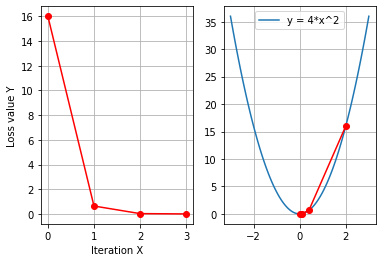

In [10]:
import torch
import matplotlib.pyplot as plt

def func(x_t):
    return torch.pow(2*x_t, 2)

x = torch.tensor([2.], requires_grad=True)
# 记录loss迭代次数，画曲线
iter_rec, loss_rec, x_rec = list(), list(), list()

# 实验学习率： 0.01 0.02 0.03 0.1 0.2 0.3 0.4
lr = 0.1    # 正常的梯度下降
# lr = 0.125      # 当学习率设置0.125 一下子求出一个最优解
                # x=0 y=0 在x=0处梯度等于0 x的值x=x-lr*x.grad就不用更新了
                # 后续再多少次迭代 都固定在最优点

# lr = 0.2      # x从2.0一下子跨过0点，到了左侧负数区域
# lr = 0.3      # 梯度越来越大 梯度爆炸
max_iteration = 4
for i in range(max_iteration):
    y = func(x)   # 得出loss值
    y.backward()  # 计算x的梯度
    print("Iter:{}, X:{:8}, X.grad:{:8}, loss:{:10}".format(
        i, x.detach().numpy()[0], x.grad.detach().numpy()[0], y.item()))
    x_rec.append(x.item())      # 梯度下降点 列表
    # 更新参数
    x.data.sub_(lr * x.grad)    # x = x - x.grad
    x.grad.zero_()
    iter_rec.append(i)          # 迭代次数 列表
    loss_rec.append(y.item())  # 损失值 列表，这里将y改为y.item()以获取标量值
# 迭代次数-损失值 关系图
plt.subplot(121).plot(iter_rec, loss_rec, '-ro')
plt.grid()
plt.xlabel("Iteration X")
plt.ylabel("Loss value Y")
# 函数曲线-下降轨迹 显示图
x_t = torch.linspace(-3, 3, 100)
y = func(x_t)
plt.subplot(122).plot(x_t.detach().numpy(), y.detach().numpy(), label="y = 4*x^2")
y_rec = [func(torch.tensor(i)).item() for i in x_rec]
print('x_rec--->', x_rec)
print('y_rec--->', y_rec)
# 指定线的颜色和样式（-ro：红色圆圈，b-：蓝色实线等）
plt.subplot(122).plot(x_rec, y_rec, '-ro')
plt.grid()
plt.legend()
plt.show()

### 等间隔学习率衰减
训练过程中，学习率会按照固定的轮数(epoch)进行固定倍数的衰减。

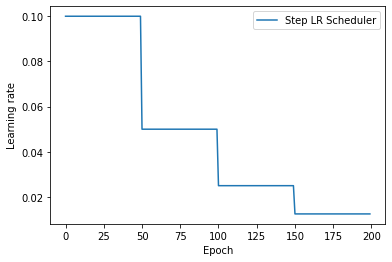

In [11]:
import torch
import matplotlib.pyplot as plt
from torch import optim

LR = 0.1  # 设置学习率初始化值为0.1
iteration = 10
max_epoch = 200
# 1 初始化参数
y_true = torch.tensor([0])
x = torch.tensor([1.0])
w = torch.tensor([1.0], requires_grad=True)
# 2.优化器
optimizer = optim.SGD([w], lr=LR, momentum=0.9)
# 3.设置学习率下降策略 参1：优化器 参2：学习率下降的轮数间隔 参3：学习率下降的倍数
scheduler_lr = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
# 4.获取学习率的值和当前的epoch
lr_list, epoch_list = [], []
for epoch in range(max_epoch):
    lr_list.append(scheduler_lr.get_last_lr()) # 获取当前lr
    epoch_list.append(epoch) # 获取当前的epoch
    for i in range(iteration):  # 遍历每一个batch数据
        loss = (w*x-y_true)**2  # 目标函数
        optimizer.zero_grad()
        # 反向传播
        loss.backward()
        optimizer.step()
    # 更新下一个epoch的学习率
    scheduler_lr.step()
# 5.绘制学习率变化的曲线
plt.plot(epoch_list, lr_list, label="Step LR Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.legend()
plt.show()

### 指定间隔学习率衰减
训练过程中，可以指定在某些轮数(epoch)进行固定倍数的衰减。

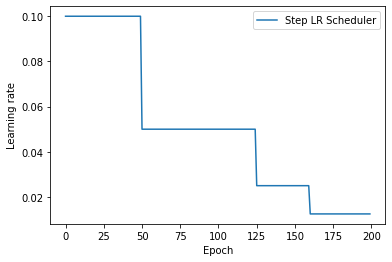

In [12]:
import torch
from torch import optim
import matplotlib.pyplot as plt

LR = 0.1
iteration = 10
max_epoch = 200
# 1.初始化参数
y_true = torch.tensor([0])
x = torch.tensor([1.0])
w = torch.tensor([1.0], requires_grad=True)
milestones = [50, 125, 160]
# 2.优化器
optimizer = optim.SGD([w], lr=LR, momentum=0.9)
# 3.设置学习率下降策略 参1：优化器 参2：需要更新学习率的轮数 参3：指定间隔的倍数
scheduler_lr = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.5)
# 4.获取学习率的值和当前的epoch
lr_list, epoch_list = [], []
for epoch in range(max_epoch):
    lr_list.append(scheduler_lr.get_last_lr()) # 获取当前lr
    epoch_list.append(epoch) # 获取当前的epoch
    for i in range(iteration):  # 遍历每一个batch数据
        loss = (w*x-y_true)**2  # 目标函数
        optimizer.zero_grad()
        # 反向传播
        loss.backward()
        optimizer.step()
    # 更新下一个epoch的学习率
    scheduler_lr.step()
# 5.绘制学习率变化的曲线
plt.plot(epoch_list, lr_list, label="Step LR Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.legend()
plt.show()

### 按指数学习率衰减
训练过程中，可以按照指数的方式，将学习率进行衰减。
$ \eta = \eta * \gamma ^ {epoch} $

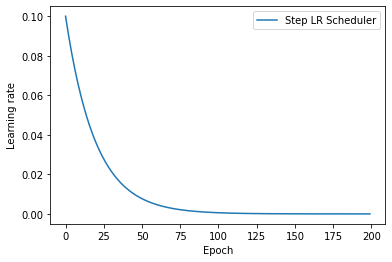

In [14]:
import torch
from torch import optim
import matplotlib.pyplot as plt

LR = 0.1
iteration = 10
max_epoch = 200
# 1.初始化参数
y_true = torch.tensor([0])
x = torch.tensor([1.0])
w = torch.tensor([1.0], requires_grad=True)
# 2.优化器
optimizer = optim.SGD([w], lr=LR, momentum=0.9)
gamma = 0.95
# 3.设置学习率下降策略 参1：优化器 参2：衰减的指数
scheduler_lr = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
# 4.获取学习率的值和当前的epoch
lr_list, epoch_list = [], []
for epoch in range(max_epoch):
    lr_list.append(scheduler_lr.get_last_lr()) # 获取当前lr
    epoch_list.append(epoch) # 获取当前的epoch
    for i in range(iteration):  # 遍历每一个batch数据
        loss = (w*x-y_true)**2  # 目标函数
        optimizer.zero_grad()
        # 反向传播
        loss.backward()
        optimizer.step()
    # 更新下一个epoch的学习率
    scheduler_lr.step()
# 5.绘制学习率变化的曲线
plt.plot(epoch_list, lr_list, label="Step LR Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.legend()
plt.show()

### 正则化
- 在设计机器学习算法时希望在新样本上的泛化能力强。许多机器学习算法都采用相关的策略来减小测试误差，这些策略被统称为正则化
- 神经网络强大的表示能力经常遇到过拟合，所以需要使用不同形式的正则化策略
- 目前在深度学习中使用较多的策略有范数惩罚，DropOut，特殊的网络层等，接下来我们对其进行详细的介绍

### Drop正则化
在训练深层神经网络时，由于模型参数较多，在数据量不足的情况下，很容易过拟合。Dropout（中文翻译成随机失活）是一个简单有效的正则化方法。
- 在训练过程中，Dropout的实现是**让神经元以超参数p（丢弃概率）的概率停止工作或者激活被置为0,未被置为0的进行缩放，缩放比例为1/(1-p)**。训练过程可以认为是对完整的神经网络的一些子集进行训练，每次基于输入数据只更新子网络的参数
- 在实际应用中，Dropout参数p的概率通常取值在0.2到0.5之间
  - 对于较小的模型或较复杂的任务，丢弃率可以选择0.3或更小
  - 对于非常深的网络，较大的丢弃率（如0.5或0.6）可能会有效防止过拟合
  - 实际应用中，通常会在全连接层（激活函数后）之后添加Dropout层
- **在测试过程中，随机失活不起作用**
  - 在测试阶段，使用所有的神经元进行预测，以获得更稳定的结果
  - 直接使用训练好的模型进行测试，由于所有的神经元都参与计算，输出的期望值会比训练阶段高。测试阶段的期望输出是 E[x_test] = x
  - 测试/推理模式：model.eval()
- **缩放的必要性**
  - 在训练阶段，将参与计算的神经元的输出除以(1-p)
  - 经过Dropout后的期望输出变为 E[x_dropout] = [(1-p) * x] / (1-p) = x，与测试阶段的期望输出一致
  - 训练模型：model.train()

In [8]:
import torch
from torch import nn

# 1. 创建隐藏层输出结果
t1 = torch.randint(0, 10, (1, 4)).float()
print(t1)
# 2. 进入下一层 加权求和 和 激活函数计算
linear1 = nn.Linear(4, 5)
l1 = linear1(t1)
print(l1)
output = torch.relu(l1)
print(output)

# 3. 添加Dropout，随机失活
dropout = nn.Dropout(p=0.5)  # 每个神经元丢弃概率为0.3
output = dropout(output)
print(output)

tensor([[4., 5., 5., 4.]])
tensor([[ 0.6202,  0.8186,  3.6934, -1.2038, -2.4375]],
       grad_fn=<AddmmBackward0>)
tensor([[0.6202, 0.8186, 3.6934, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)
tensor([[0.0000, 0.0000, 7.3869, 0.0000, 0.0000]], grad_fn=<MulBackward0>)


### 批量归一化
批量归一化（Batch Normalization）是一种常用的正则化策略，它可以在训练过程中对神经网络的输入进行归一化处理，从而提高模型的训练效率和泛化性能。
先对数据标准化，然后对数据重构(放缩+平移)，如下所示：
$ f(x) = \lambda * \frac{x-E(x)}{\sqrt{Var(x)} + \epsilon} + \beta $
- $\lambda$：缩放参数，用于控制输出的方差
- $\beta$：偏移参数，用于控制输出的均值
- $\epsilon$：一个很小的数，用于避免除零错误，通常为1e-5
- E(x)：输入数据的均值
- Var(x)：输入数据的方差

**批量归一化层在计算机视觉领域使用较多**

In [7]:
import torch
from torch import nn


input_2d = torch.randint(0, 10, size=(1, 2, 3, 4)).float()
print(f"input_2d: {input_2d}")
# 参数1：输入数据的通道数（特征数），参数2：eps小常数，防止除零错误，参数3：动量系数，用于计算移动过平均统计量的动量值，参数4：默认为True，表示使用可学习的变换系数(λ和β)
bn = nn.BatchNorm2d(num_features=2, eps=1e-5, momentum=0.1, affine=True)
output = bn(input_2d)
print("output-->", output)
print(output.size())

print(bn.weight)
print(bn.bias)
print("======================================================================")

input_1d = torch.randn(size=(2,2))
linear = nn.Linear(2, 4)
bn = nn.BatchNorm1d(num_features=4, eps=1e-5, momentum=0.1, affine=True)
output = bn(linear(input_1d))
print(output)

input_2d: tensor([[[[2., 4., 8., 7.],
          [8., 9., 0., 9.],
          [1., 1., 0., 8.]],

         [[3., 3., 6., 1.],
          [3., 8., 9., 1.],
          [4., 0., 6., 9.]]]])
output--> tensor([[[[-0.7670, -0.2092,  0.9065,  0.6276],
          [ 0.9065,  1.1854, -1.3249,  1.1854],
          [-1.0459, -1.0459, -1.3249,  0.9065]],

         [[-0.4702, -0.4702,  0.5256, -1.1341],
          [-0.4702,  1.1894,  1.5213, -1.1341],
          [-0.1383, -1.4660,  0.5256,  1.5213]]]],
       grad_fn=<NativeBatchNormBackward0>)
torch.Size([1, 2, 3, 4])
Parameter containing:
tensor([1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0.], requires_grad=True)
tensor([[ 0.9998,  0.9998, -0.9977, -0.9998],
        [-0.9998, -0.9998,  0.9977,  0.9998]],
       grad_fn=<NativeBatchNormBackward0>)
